## Directory check

In [3]:
import numpy as np
import pandas as pd
data=pd.read_csv("heart_disease_uci.csv")

This cell imports two important Python libraries: NumPy and Pandas.
NumPy helps with numerical calculations, while Pandas helps in handling tabular data.
The read_csv() function is used to load the heart disease dataset from your system.
The dataset file is stored in CSV format, which is common for data analysis.
The loaded data is saved into a variable called data.
This data variable will be used in the next steps for analysis and model training.

In [4]:
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


This line displays the first 5 rows of the dataset.
It helps you quickly understand what kind of data is present.
You can see the column names and sample values for each feature.
This is useful to check whether the dataset loaded correctly.
It also helps identify if the data looks meaningful or has obvious issues.
This step is usually done before cleaning or processing the data.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


This line shows basic information about the dataset.
It displays the total number of rows and columns present.
It tells the data type of each column (integer, float, object, etc.).
It helps identify which columns have missing values.
This step is important to decide if data cleaning is needed.
It gives a quick overview of the dataset structure before preprocessing.

## Drop id and dataset columns

In [6]:
data=data.drop(['id','dataset'],axis=1,errors="ignore")

This line removes the columns id and dataset from the data.
These columns are not useful for predicting heart disease.
 The axis=1 tells Pandas to remove columns, not rows.
 The errors="ignore" option avoids errors if the columns do not exist.
 This step helps keep only meaningful features for the model.
 Removing unnecessary columns improves model performance and clarity.

## Checking Missing values

In [7]:
dataMissing=data.isnull().sum()
dataMissing

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

 This cell checks the dataset for missing (null) values.
 The isnull() function identifies empty or missing entries.
 The sum() function counts how many missing values are in each column.
 The result is stored in a variable called dataMissing.
 Displaying dataMissing helps you see which columns need cleaning.
 This step is important before training the model to avoid errors.

## Check whether a specific column has outliers using a boxplot.

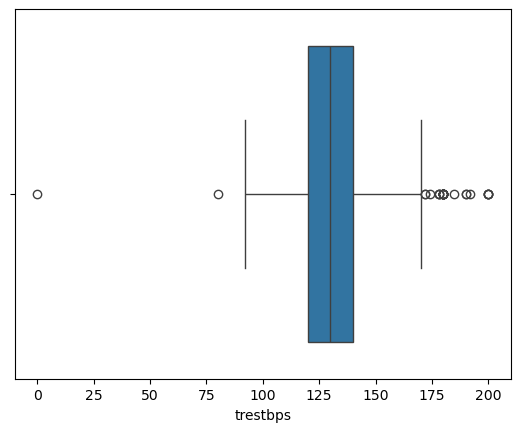

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=data['trestbps'])
plt.show()



This cell imports Seaborn and Matplotlib, which are used for data visualization.
A box plot is created for the trestbps column (resting blood pressure).
The box plot helps visualize the distribution of blood pressure values.
It clearly shows minimum, maximum, median, and outliers.
Outliers may indicate unusual or extreme blood pressure values.
This visualization helps decide whether data cleaning is required.

## outlier check second way for specific columns

In [9]:

Q1 = data['trestbps'].quantile(0.25)
Q3 = data['trestbps'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
outliers = data[(data['trestbps'] < lower_bound) | (data['trestbps'] > upper_bound)]
print(f"Total outliers count: {len(outliers)}")
print("outliers are :\n", outliers['trestbps'])

Lower Bound: 90.0
Upper Bound: 170.0
Total outliers count: 28
outliers are :
 14     172.0
83     180.0
126    200.0
172    174.0
183    178.0
188    192.0
201    180.0
213    178.0
231    180.0
338    190.0
375    180.0
387    180.0
475    180.0
484    180.0
548    200.0
569    180.0
595    180.0
644     80.0
647    180.0
680    200.0
700    185.0
701    200.0
727    180.0
753      0.0
779    178.0
854    172.0
889    180.0
896    190.0
Name: trestbps, dtype: float64


This cell is used to detect outliers in the trestbps (resting blood pressure) column.
Q1 and Q3 calculate the 25th percentile and 75th percentile of blood pressure values.
IQR (Interquartile Range) is the difference between Q3 and Q1.
The lower bound and upper bound define the normal range for blood pressure values.
Any value below the lower bound or above the upper bound is considered an outlier.
The code filters and stores these abnormal values in the outliers variable.
It prints how many outliers exist in the dataset.
This step helps identify extreme values that may affect model accuracy.

## checking outliers for all columns at the same time

In [10]:

numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"Column: {col}")
        print(f"-----------------------------")
        print(f"Total outliers: {len(outliers)}")
        print(f"Lower Limit: {lower_bound}, Upper Limit: {upper_bound}")
        print(f"Outlier Values (Top 5): {outliers[col].values[:5]}")
        print("\n") 

Column: trestbps
-----------------------------
Total outliers: 28
Lower Limit: 90.0, Upper Limit: 170.0
Outlier Values (Top 5): [172. 180. 200. 174. 178.]


Column: chol
-----------------------------
Total outliers: 183
Lower Limit: 35.5, Upper Limit: 407.5
Outlier Values (Top 5): [417. 564. 409. 412. 468.]


Column: thalch
-----------------------------
Total outliers: 2
Lower Limit: 64.5, Upper Limit: 212.5
Outlier Values (Top 5): [60. 63.]


Column: oldpeak
-----------------------------
Total outliers: 16
Lower Limit: -2.25, Upper Limit: 3.75
Outlier Values (Top 5): [6.2 4.  5.6 4.  4.2]


Column: ca
-----------------------------
Total outliers: 20
Lower Limit: -1.5, Upper Limit: 2.5
Outlier Values (Top 5): [3. 3. 3. 3. 3.]




This cell identifies outliers in all numerical columns of the dataset.
It first selects columns that contain only numbers (integers and floats).
The for loop goes through each numerical column one by one.
For each column, it calculates Q1, Q3, and the Interquartile Range (IQR).
Using IQR, it defines the lower and upper limits for normal values.
Any value outside this range is considered an outlier.
If outliers exist, the column name and outlier details are printed.
It shows how many outliers are present and the valid value range.
This step helps decide which columns need cleaning or special handling before training the model.

## Determine outlier and solve the outlier with help to capping

In [11]:
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"Column: {col} | Outliers found: {len(outliers)}")
        #outlier problem solve
        data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
        data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
        
        print(f"--> Fixed outliers for {col}")
        print("-----------------------------")

print("All outliers handled successfully!")

Column: trestbps | Outliers found: 28
--> Fixed outliers for trestbps
-----------------------------
Column: chol | Outliers found: 183
--> Fixed outliers for chol
-----------------------------
Column: thalch | Outliers found: 2
--> Fixed outliers for thalch
-----------------------------
Column: oldpeak | Outliers found: 16
--> Fixed outliers for oldpeak
-----------------------------
Column: ca | Outliers found: 20
--> Fixed outliers for ca
-----------------------------
All outliers handled successfully!


This cell handles outliers in all numerical columns of the dataset. It first selects all columns that contain numerical values. The loop goes through each numerical column one by one. For every column, it calculates the IQR-based lower and upper limits. Values outside these limits are identified as outliers. Instead of removing rows, extreme values are capped at the boundary values. This process is called outlier capping or clipping. It helps prevent extreme values from negatively affecting the model.
At the end, the message confirms that all outliers are handled successfully.

## Numerical missing columns Fill the remaining data using the median

In [12]:
numerical_cols=data.select_dtypes(include=["float64","int64"]).columns
numerical_cols
for col in numerical_cols:
    median_val=data[col].median()
    print(f"colName:{col} and Median_Values:{median_val}") 
    data[col]=data[col].fillna(median_val)
    

colName:age and Median_Values:54.0
colName:trestbps and Median_Values:130.0
colName:chol and Median_Values:223.0
colName:thalch and Median_Values:140.0
colName:oldpeak and Median_Values:0.5
colName:ca and Median_Values:0.0
colName:num and Median_Values:1.0


 This cell selects all numerical columns from the dataset. It then loops through each numerical column one by one. For each column, it calculates the median value. The median is printed so you can see the replacement value used. Any missing values (NaN) in that column are replaced with the median. Median is chosen because it is less affected by outliers. This ensures no missing numerical data remains in the dataset. Filling missing values helps the model train without errors.

## Again check missing values in Numerical columns

In [13]:
data.isnull().sum()

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs          90
restecg       2
thalch        0
exang        55
oldpeak       0
slope       309
ca            0
thal        486
num           0
dtype: int64

This line checks the dataset again for missing values. It counts how many null values are present in each column. This is done after filling missing values in previous steps. The result helps confirm that data cleaning was successful. If all values are zero, it means there are no missing entries left. This ensures the dataset is ready for model training.

## Objects missing columns Fill missing values in a dataset with the mode

In [14]:
objects_col=data.select_dtypes(include=["object"]).columns
objects_col
for col in objects_col:
    mode_cal=data[col].mode()[0]
    print(f"col_Name:{col} and mode:{mode_cal}")
    data[col]=data[col].fillna(mode_cal)

col_Name:sex and mode:Male
col_Name:cp and mode:asymptomatic
col_Name:fbs and mode:False
col_Name:restecg and mode:normal
col_Name:exang and mode:False
col_Name:slope and mode:flat
col_Name:thal and mode:normal


C:\Users\iamna\AppData\Local\Temp\ipykernel_27644\1447902019.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col]=data[col].fillna(mode_cal)


This cell selects all categorical (object-type) columns from the dataset. These columns usually contain text values like categories or labels. The loop goes through each categorical column one by one. For each column, it calculates the mode, which is the most common value. The mode value is printed so you know what is being used for replacement. Any missing values in that column are filled with the mode. Mode is used because it best represents common categorical data. This ensures there are no missing categorical values before model training.

## Again check missing values in Objects columns

In [15]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

This line checks the dataset for any remaining missing values. It counts the number of null values in each column. This step is repeated to double-confirm data cleanliness. If all values are 0, it means no missing data exists. This ensures the dataset is fully prepared for feature selection and model training. It acts as a final safety check before moving forward.

## Converting the target variable into binary.

In [16]:
data['num']=data['num'].apply(lambda x: 1 if x>0 else 0)

This line modifies the num column, which is the target variable. Originally, num may contain values like 0, 1, 2, 3, 4. The lambda function converts all values greater than 0 to 1. Value 0 remains 0, meaning no heart disease. After this step, the problem becomes binary classification. This makes the model simpler: 1 = Heart Disease, 0 = No Heart Disease.

In [17]:
data[["num"]]

,num
0,0
1,1
2,1
3,0
4,0
...,...
915,1
916,0
917,1
918,0


This line selects only the num column from the dataset. The double brackets [[ ]] keep the result in DataFrame format. It is usually done to clearly view or inspect the target variable. This helps confirm that the values are now 0 and 1 only. It ensures the target column is correctly prepared for model training. This step is often used before splitting data into features and labels.

## On the X-axis, I kept the dataset columns except the Num/ID and target columns. On the Y-axis, I kept only the target column, which is Num.

In [18]:
selected_features = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "thalch"
]

X = data[selected_features]
y = data["num"]


This cell defines a list of important input features needed for prediction.
Only simple and user-understandable features are selected.
The selected features are extracted from the dataset into X.
X contains the input data used to train the model.
The num column is assigned to y as the target variable.
This step separates features (X) and labels (y) for model training.

In [19]:
X.head()

,age,sex,cp,trestbps,chol,fbs,thalch
0,63,Male,typical angina,145.0,233.0,True,150.0
1,67,Male,asymptomatic,160.0,286.0,False,108.0
2,67,Male,asymptomatic,120.0,229.0,False,129.0
3,37,Male,non-anginal,130.0,250.0,False,187.0
4,41,Female,atypical angina,130.0,204.0,False,172.0


This line displays the first 5 rows of the feature dataset X.
It helps you quickly see the values of the selected input features.
You can verify that only the intended columns are present.
This confirms that feature selection was done correctly.
It also helps spot any unusual or incorrect values early.
This step is useful before encoding or scaling the data.

In [20]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: num, dtype: int64

This line displays the first 5 values of the target variable y.
It helps you check what the model is trying to predict.
You can confirm that the values are now binary (0 or 1).
0 represents no heart disease and 1 represents heart disease.
This step verifies that target conversion was done correctly.
It ensures the labels are ready for training the classification model.

## Encoding Object datatype and bool datatype in X axis

In [21]:
# Use ALL features this time — not just 7
X = data.drop('num', axis=1)
y = data['num']

# One-hot encode
X = pd.get_dummies(X, drop_first=True, dtype=int)
X = X.astype(float)
X.info()
print("Feature count:", X.shape[1])
print("Features:", list(X.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    float64
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   fbs                       920 non-null    float64
 4   thalch                    920 non-null    float64
 5   exang                     920 non-null    float64
 6   oldpeak                   920 non-null    float64
 7   ca                        920 non-null    float64
 8   sex_Male                  920 non-null    float64
 9   cp_atypical angina        920 non-null    float64
 10  cp_non-anginal            920 non-null    float64
 11  cp_typical angina         920 non-null    float64
 12  restecg_normal            920 non-null    float64
 13  restecg_st-t abnormality  920 non-null    float64
 14  slope_flat

This code converts categorical (text) data in X into numeric form.
pd.get_dummies() creates separate columns for each category value.
drop_first=True removes one category to avoid duplicate information.
dtype=int ensures all encoded values are integers.
X.astype(int) confirms that all columns are numeric.
X.info() displays the final structure of the dataset before model training.

## Train / Temp Split

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train size  : {X_train.shape[0]}")
print(f"Val size    : {X_val.shape[0]}")
print(f"Test size   : {X_test.shape[0]}")

Train size  : 644
Val size    : 138
Test size   : 138


This cell imports the function used to split data into training and testing sets.
The dataset is split so the model does not learn from all the data at once.
 test_size=0.3 means 30% of the data is kept aside for testing.
 X_train and y_train are used to train the model.
 X_temp and y_temp store the remaining data for further splitting or evaluation.
 random_state=42 ensures the split is reproducible every time.

In [23]:
print("X_train:")
print(X_train)

print("\nX_temp:")
print(X_temp)

print("\ny_train:")
print(y_train)

print("\ny_temp:")
print(y_temp)


X_train:
      age  trestbps   chol  fbs  thalch  exang  oldpeak   ca  sex_Male  \
410  49.0     120.0  297.0  0.0   132.0    0.0     1.00  0.0       1.0   
567  52.0     160.0  246.0  0.0    82.0    1.0     3.75  0.0       1.0   
389  47.0     130.0  223.0  0.0   145.0    0.0     2.00  0.0       0.0   
257  76.0     140.0  197.0  0.0   116.0    0.0     1.10  0.0       0.0   
347  40.0     140.0  223.0  0.0   188.0    0.0     0.00  0.0       1.0   
..    ...       ...    ...  ...     ...    ...      ...  ...       ...   
612  43.0     115.0   35.5  0.0   145.0    1.0     2.00  0.0       1.0   
624  50.0     120.0   35.5  0.0   156.0    1.0     0.00  0.0       1.0   
917  55.0     122.0  223.0  1.0   100.0    0.0     0.00  0.0       1.0   
517  51.0     160.0  303.0  0.0   150.0    1.0     1.00  0.0       0.0   
317  35.0     120.0  308.0  0.0   180.0    0.0     0.00  0.0       1.0   

     cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_normal  \
410                 0.0 

This cell prints the contents of the training and temporary datasets. X_train shows the input features used for training the model. X_temp contains the data kept aside for testing or validation. y_train displays the target values corresponding to the training data. y_temp shows the target values for the remaining data. Printing these helps verify that the split was done correctly. It also allows you to visually inspect the data before model training.

In [24]:
print("X_val:")
print(X_val)

print("\nX_test:")
print(X_test)

print("\ny_val:")
print(y_val)

print("\ny_test:")
print(y_test)


X_val:
      age  trestbps   chol  fbs  thalch  exang  oldpeak   ca  sex_Male  \
273  71.0     112.0  149.0  0.0   125.0    0.0      1.6  0.0       0.0   
339  39.0     120.0  339.0  0.0   170.0    0.0      0.0  0.0       1.0   
862  58.0     130.0  232.0  0.0   140.0    0.0      0.5  0.0       1.0   
617  47.0     110.0   35.5  0.0   120.0    1.0      0.0  0.0       1.0   
286  58.0     170.0  225.0  1.0   146.0    1.0      2.8  2.0       0.0   
..    ...       ...    ...  ...     ...    ...      ...  ...       ...   
859  58.0     150.0  219.0  0.0   118.0    1.0      0.0  0.0       1.0   
659  56.0     140.0   35.5  0.0   121.0    1.0      1.8  0.0       1.0   
529  38.0     110.0  223.0  0.0   150.0    1.0      1.0  0.0       1.0   
815  63.0     160.0  267.0  1.0    88.0    1.0      2.0  0.0       1.0   
1    67.0     160.0  286.0  0.0   108.0    1.0      1.5  2.5       1.0   

     cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_normal  \
273                 0.0   

This cell prints the validation and test datasets. X_val shows the feature values used for model validation. X_test contains feature values used for final testing. y_val displays the target labels for the validation set. y_test displays the target labels for the test set. Printing these helps confirm the data is split correctly. It also allows you to inspect the data before training the model.

## Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler
#scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


This cell imports the StandardScaler, which is used to scale numeric data. Scaling helps bring all feature values to a similar range. The scaler is fit only on training data to avoid data leakage. X_train_scaled is used to learn scaling parameters (mean and standard deviation).
 The same scaler is applied to validation and test data.
 This keeps data transformation consistent across all datasets.
Scaling improves model performance and stability.

## Model Train

### LogisticRegression

In [26]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(C=1000,max_iter=1000)
model.fit(X_train_scaled,y_train)

LogisticRegression(C=1000, max_iter=1000)

This cell imports the Logistic Regression algorithm from scikit-learn.
 Logistic Regression is used for binary classification problems.
 C=1000 controls how much the model tries to fit the training data. A higher C value allows the model to learn more detailed patterns. max_iter=1000 gives the model enough iterations to fully learn. The model is trained using the scaled training data.
 After this step, the model is ready to make predictions.

### RandomForestClassifier

In [27]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

This cell imports the Random Forest Classifier algorithm. Random Forest builds many decision trees and combines their results.
 n_estimators=100 means the model uses 100 decision trees.
 random_state=42 ensures the same results every time the code runs.
 The model is trained using the scaled training data.
 Random Forest can capture complex patterns better than a single model.
 After training, the model is ready for evaluation and prediction.

## validation Accuracy Check

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_val_pred = model.predict(X_val_scaled)
print("Validation Set Metrics:")
print(confusion_matrix(y_val, y_val_pred))
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, average='weighted'))
print("Recall   :", recall_score(y_val, y_val_pred, average='weighted'))
print("F1 Score :", f1_score(y_val, y_val_pred, average='weighted'))
print("\n")

Validation Set Metrics:
[[47 14]
 [ 9 68]]
Accuracy : 0.8333333333333334
Precision: 0.8336962833914053
Recall   : 0.8333333333333334
F1 Score : 0.8323926248454551




## check accuracy using the test dataset

In [29]:
y_test_pred = model.predict(X_test_scaled)
print("Test Set Metrics:")
print(confusion_matrix(y_test, y_test_pred))
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

Test Set Metrics:
[[51 11]
 [12 64]]
Accuracy : 0.8333333333333334
Precision: 0.8336507936507936
Recall   : 0.8333333333333334
F1 Score : 0.8334481236203091


This cell makes predictions using the test dataset, which the model has never seen before. The confusion matrix shows how many predictions are correct and incorrect. Accuracy shows the overall correctness of the model.
 Precision indicates how reliable the positive predictions are.
Recall measures how well the model finds actual heart disease cases.
F1 Score balances precision and recall into a single value.
These metrics reflect the real-world performance of the model.
This step confirms whether the model is ready for deployment.

## check multiple models at the same time

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "Support Vector Machine (SVM)": SVC(kernel='rbf', probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

print("Checking which model is perfect for your data...\n")

best_model_name = ""
best_acc = 0

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred) 
    
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall  : {recall:.4f}")
    print("-" * 30)
    
    if acc > best_acc:
        best_acc = acc
        best_model_name = name

print(f"\n🏆 Winner Model: {best_model_name} with {best_acc:.4f} accuracy!")

Checking which model is perfect for your data...

Model: Logistic Regression
Accuracy: 0.8116
Recall  : 0.8158
------------------------------
Model: Random Forest
Accuracy: 0.8043
Recall  : 0.8158
------------------------------
Model: Support Vector Machine (SVM)
Accuracy: 0.8333
Recall  : 0.8816
------------------------------


C:\Users\iamna\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:28:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBoost
Accuracy: 0.8551
Recall  : 0.8553
------------------------------

🏆 Winner Model: XGBoost with 0.8551 accuracy!


In [31]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

model = XGBClassifier()

grid = GridSearchCV(model, params, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


This cell imports multiple machine learning models like Logistic Regression, Random Forest, SVM, and XGBoost. All models are stored in a dictionary so they can be tested easily in a loop. Each model is trained using the same training data for fair comparison.
The trained model then makes predictions on the test dataset.
Accuracy checks how many predictions are correct overall.
Recall checks how well the model detects heart disease cases. The results for each model are printed for comparison.
The model with the highest accuracy is selected as the best model.
This step helps choose the most suitable algorithm for deployment.

## Visual Representation

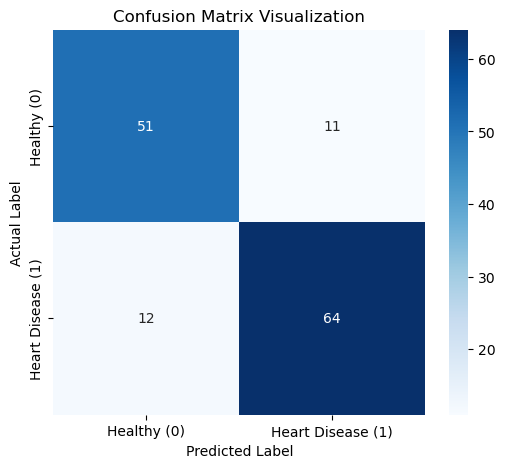

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy (0)', 'Heart Disease (1)'],
            yticklabels=['Healthy (0)', 'Heart Disease (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Visualization')
plt.show()

 This cell imports libraries used for data visualization. The confusion matrix is created using actual and predicted test labels.A figure size is set to make the chart easy to read. A heatmap is used to visually display correct and incorrect predictions. The numbers inside the boxes show how many predictions fall in each category. Axis labels explain predicted vs actual results clearly. Blue color intensity helps quickly identify strong and weak areas.m This visualization makes model performance easy to understand for non-technical users.

In [37]:
import pandas as pd

# Step 1: User input
user_input = {
   "age": 64,
    "sex": "Male",
    "cp": "typical angina",
    "trestbps": 170,
    "chol": 260,
    "fbs": 1,
    "restecg": "abnormal",
    "thalach": 105
}

user_df = pd.DataFrame([user_input])

# Step 2: Encode like training
user_df_encoded = pd.get_dummies(user_df, drop_first=True)
user_df_encoded = user_df_encoded.reindex(columns=X.columns, fill_value=0)

# Step 3: Scale
user_scaled = scaler.transform(user_df_encoded)

# Step 4: Predict
prediction = grid.best_estimator_.predict(user_scaled)
probability = grid.best_estimator_.predict_proba(user_scaled)

# Output
if prediction[0] == 1:
    print("Heart Disease Risk Detected")
else:
    print("No Heart Disease Detected")

print("Prediction probability:", probability)


No Heart Disease Detected
Prediction probability: [[0.5320138  0.46798623]]


This cell creates a sample user input with age, gender, chest pain, and other health details.
The input is converted into a DataFrame, just like the training data format.
 Categorical values (like gender and chest pain type) are converted into numbers using one-hot encoding.
 The encoded input is aligned with the same feature columns used during training. The data is then scaled using the previously trained scaler. The trained model uses this processed data to make a prediction  The prediction tells whether heart disease risk is detected or not.The model also returns a probability score showing how confident the prediction is. This step simulates how the model will work in a real application.

In [39]:
import pickle

with open("heart_model.pkl", "wb") as f:
    pickle.dump(
        {
            "model": model,
            "scaler": scaler,
            "features": X.columns.tolist()
        },
        f
    )


This cell saves the trained machine learning model to a file.
pickle is used to store Python objects so they can be reused later.
The file name heart_model.pkl is created to store everything together.
The trained model, scaler, and feature names are saved in one place.
Saving feature names ensures correct input alignment during prediction.
This file allows the model to be loaded later without retraining.
It is mainly used for Streamlit app and deployment.